# CS301 Project - Stage 2
## Model Optimization & Comparative Analysis (Heart Disease Classification)

This notebook follows the Stage 2 project description order:
1. Advanced Modeling (two additional models)
2. Hyperparameter Tuning + k-fold CV
3. Feature Engineering (optional)
4. Performance Comparison and best-model selection


In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
ROOT = Path.cwd().resolve()
PLOT_DIR = ROOT / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)


## Data Preparation


In [12]:
df = pd.read_csv('../data/heart_disease_dataset.csv')

# align with Stage 1 cleaning decision
if 'Alcohol Intake' in df.columns:
    df = df.drop(columns=['Alcohol Intake'])

df = df.drop_duplicates()
df = df.dropna(subset=['Heart Disease'])
df['Heart Disease'] = df['Heart Disease'].astype(int)

numeric_cols = ['Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Exercise Hours', 'Stress Level', 'Blood Sugar']
categorical_cols = ['Gender', 'Smoking', 'Family History', 'Obesity', 'Exercise Induced Angina', 'Chest Pain Type']

X = df[numeric_cols + categorical_cols]
y = df['Heart Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Shape:', df.shape)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Class balance:', y.value_counts().to_dict())

Shape: (1000, 15)
Train: (800, 13) Test: (200, 13)
Class balance: {0: 608, 1: 392}


## 1) Advanced Modeling
Models:
- Baseline: Logistic Regression (from Stage 1 reference)
- Additional Model 1: Decision Tree
- Additional Model 2: Random Forest


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ]
)

lr_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print('Logistic Regression')
print('Accuracy:', round(lr_acc, 4))
print('F1-score:', round(lr_f1, 4))

Logistic Regression
Accuracy: 0.85
F1-score: 0.8148


## 2) Hyperparameter Tuning + k-Fold CV


In [14]:
# Decision Tree: GridSearchCV
dt_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 5, 7, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=1
)
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
dt_pred = best_dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print('Decision Tree best params:', dt_grid.best_params_)
print('Decision Tree accuracy:', round(dt_acc, 4))
print('Decision Tree f1:', round(dt_f1, 4))

Decision Tree best params: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Decision Tree accuracy: 1.0
Decision Tree f1: 1.0


In [15]:
# Random Forest: RandomizedSearchCV
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_param_dist = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [None, 5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=1
)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print('Random Forest best params:', rf_search.best_params_)
print('Random Forest accuracy:', round(rf_acc, 4))
print('Random Forest f1:', round(rf_f1, 4))

Random Forest best params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 15}
Random Forest accuracy: 1.0
Random Forest f1: 1.0


In [16]:
# k-fold CV scores (F1) on training data for tuned models
dt_cv_f1 = cross_val_score(best_dt, X_train, y_train, cv=5, scoring='f1')
rf_cv_f1 = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='f1')

print('Decision Tree CV F1:', np.round(dt_cv_f1, 4), 'Mean:', round(dt_cv_f1.mean(), 4))
print('Random Forest CV F1:', np.round(rf_cv_f1, 4), 'Mean:', round(rf_cv_f1.mean(), 4))

Decision Tree CV F1: [1.    1.    1.    1.    0.992] Mean: 0.9984
Random Forest CV F1: [1.    1.    1.    1.    0.992] Mean: 0.9984


## 3) Feature Engineering


In [17]:
# Optional feature engineering: interaction feature
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe['BP_x_Stress'] = X_train_fe['Blood Pressure'] * X_train_fe['Stress Level']
X_test_fe['BP_x_Stress'] = X_test_fe['Blood Pressure'] * X_test_fe['Stress Level']

numeric_cols_fe = numeric_cols + ['BP_x_Stress']
preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_fe),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ]
)

lr_fe = Pipeline([
    ('preprocess', preprocessor_fe),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_fe.fit(X_train_fe, y_train)
lr_fe_pred = lr_fe.predict(X_test_fe)
lr_fe_acc = accuracy_score(y_test, lr_fe_pred)
lr_fe_f1 = f1_score(y_test, lr_fe_pred)

print('Logistic + engineered feature')
print('Accuracy:', round(lr_fe_acc, 4))
print('F1-score:', round(lr_fe_f1, 4))

Logistic + engineered feature
Accuracy: 0.85
F1-score: 0.8148


## 4) Performance Comparison & Best Model


In [18]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': lr_acc, 'F1-Score': lr_f1},
    {'Model': 'Decision Tree (Tuned)', 'Accuracy': dt_acc, 'F1-Score': dt_f1},
    {'Model': 'Random Forest (Tuned)', 'Accuracy': rf_acc, 'F1-Score': rf_f1},
    {'Model': 'Logistic + Feature Engineering', 'Accuracy': lr_fe_acc, 'F1-Score': lr_fe_f1},
]).sort_values('F1-Score', ascending=False).reset_index(drop=True)

results

,Model,Accuracy,F1-Score
0,Decision Tree (Tuned),1.00,1.000000
1,Random Forest (Tuned),1.00,1.000000
2,Logistic Regression,0.85,0.814815
3,Logistic + Feature Engineering,0.85,0.814815


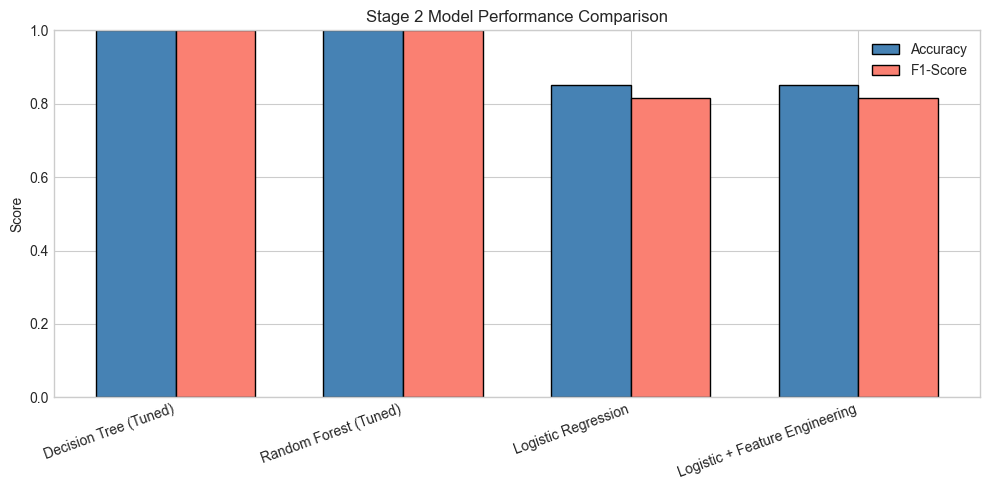

In [19]:
# Bar chart comparison
x = np.arange(len(results))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, results['Accuracy'], width, label='Accuracy', color='steelblue', edgecolor='black')
ax.bar(x + width/2, results['F1-Score'], width, label='F1-Score', color='salmon', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Stage 2 Model Performance Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot_stage2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Best model by F1-score: Decision Tree (Tuned)


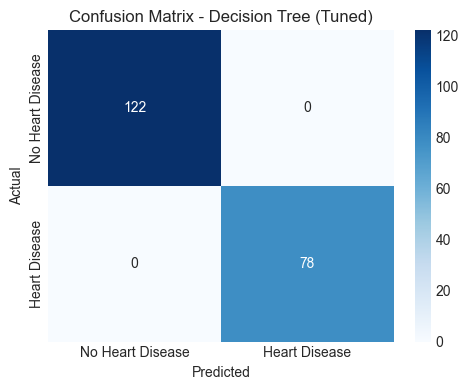


Classification Report for Best Model:
                  precision    recall  f1-score   support

No Heart Disease       1.00      1.00      1.00       122
   Heart Disease       1.00      1.00      1.00        78

        accuracy                           1.00       200
       macro avg       1.00      1.00      1.00       200
    weighted avg       1.00      1.00      1.00       200



In [20]:
best_model_name = results.iloc[0]['Model']
print('Best model by F1-score:', best_model_name)

if best_model_name == 'Decision Tree (Tuned)':
    final_pred = dt_pred
elif best_model_name == 'Random Forest (Tuned)':
    final_pred = rf_pred
elif best_model_name == 'Logistic + Feature Engineering':
    final_pred = lr_fe_pred
else:
    final_pred = lr_pred

cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot_stage2_best_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report for Best Model:')
print(classification_report(y_test, final_pred, target_names=['No Heart Disease', 'Heart Disease']))

## 5) Insight From Feature Importances + Two-Feature Retraining

After training both tree-based models, the strongest two features were:
- `Age`
- `Cholesterol`

Observed top importances:

| Feature | Importance |
|---|---:|
| num__Age | 0.558235 |
| num__Cholesterol | 0.441765 |
| cat__Smoking_Never | 0.000000 |
| cat__Chest Pain Type_Non-anginal Pain | 0.000000 |
| cat__Chest Pain Type_Atypical Angina | 0.000000 |
| cat__Exercise Induced Angina_Yes | 0.000000 |
| cat__Obesity_Yes | 0.000000 |
| cat__Family History_Yes | 0.000000 |
| cat__Diabetes_Yes | 0.000000 |
| cat__Smoking_Former | 0.000000 |

Next, we retrain tuned Decision Tree and tuned Random Forest using only these two features.

In [21]:
# Retrain with only Age and Cholesterol
two_feature_cols = ['Age', 'Cholesterol']

X2 = df[two_feature_cols]
y2 = df['Heart Disease']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

preprocessor_2f = ColumnTransformer(
    transformers=[('num', StandardScaler(), two_feature_cols)]
)

# Decision Tree (same tuned search space)
dt_pipeline_2f = Pipeline([
    ('preprocess', preprocessor_2f),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_grid_2f = GridSearchCV(
    estimator=dt_pipeline_2f,
    param_grid=dt_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=1
)
dt_grid_2f.fit(X2_train, y2_train)

best_dt_2f = dt_grid_2f.best_estimator_
dt_pred_2f = best_dt_2f.predict(X2_test)
dt_acc_2f = accuracy_score(y2_test, dt_pred_2f)
dt_f1_2f = f1_score(y2_test, dt_pred_2f)

# Random Forest (same tuned search space)
rf_pipeline_2f = Pipeline([
    ('preprocess', preprocessor_2f),
    ('model', RandomForestClassifier(random_state=42))
])

rf_search_2f = RandomizedSearchCV(
    estimator=rf_pipeline_2f,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=1
)
rf_search_2f.fit(X2_train, y2_train)

best_rf_2f = rf_search_2f.best_estimator_
rf_pred_2f = best_rf_2f.predict(X2_test)
rf_acc_2f = accuracy_score(y2_test, rf_pred_2f)
rf_f1_2f = f1_score(y2_test, rf_pred_2f)

print('Decision Tree (2 features) best params:', dt_grid_2f.best_params_)
print('Decision Tree (2 features) Accuracy:', round(dt_acc_2f, 4))
print('Decision Tree (2 features) F1:', round(dt_f1_2f, 4))

print('\nRandom Forest (2 features) best params:', rf_search_2f.best_params_)
print('Random Forest (2 features) Accuracy:', round(rf_acc_2f, 4))
print('Random Forest (2 features) F1:', round(rf_f1_2f, 4))

Decision Tree (2 features) best params: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Decision Tree (2 features) Accuracy: 1.0
Decision Tree (2 features) F1: 1.0

Random Forest (2 features) best params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 15}
Random Forest (2 features) Accuracy: 1.0
Random Forest (2 features) F1: 1.0


In [22]:
# Compare full-feature vs two-feature results for tree-based models
compare_2f = pd.DataFrame([
    {'Model': 'Decision Tree (Full Features)', 'Accuracy': dt_acc, 'F1-Score': dt_f1},
    {'Model': 'Decision Tree (Age + Cholesterol)', 'Accuracy': dt_acc_2f, 'F1-Score': dt_f1_2f},
    {'Model': 'Random Forest (Full Features)', 'Accuracy': rf_acc, 'F1-Score': rf_f1},
    {'Model': 'Random Forest (Age + Cholesterol)', 'Accuracy': rf_acc_2f, 'F1-Score': rf_f1_2f},
])

compare_2f

,Model,Accuracy,F1-Score
0,Decision Tree (Full Features),1.0,1.0
1,Decision Tree (Age + Cholesterol),1.0,1.0
2,Random Forest (Full Features),1.0,1.0
3,Random Forest (Age + Cholesterol),1.0,1.0


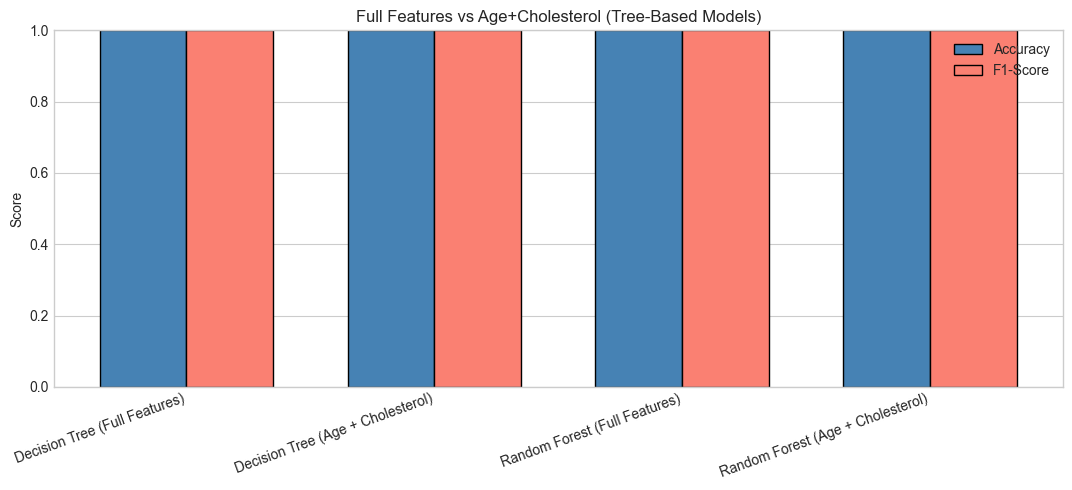

In [23]:
# Plot full vs two-feature performance
plot_df = compare_2f.copy()
x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, plot_df['Accuracy'], width, label='Accuracy', color='steelblue', edgecolor='black')
ax.bar(x + width/2, plot_df['F1-Score'], width, label='F1-Score', color='salmon', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(plot_df['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Full Features vs Age+Cholesterol (Tree-Based Models)')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot_stage2_two_feature_retrain_comparison.png', dpi=150, bbox_inches='tight')
plt.show()